# Understanding SGLD and Loss Landscapes on Toy Models

This notebook builds intuition for Stochastic Gradient Langevin Dynamics (SGLD) and local learning coefficient (LLC) estimation using small, fully visualizable models.

We start with a 2-parameter linear regression (where the loss landscape is a simple bowl), then move to a 4-parameter single-hidden-neuron MLP (where the landscape has interesting non-convex structure). For each, we:

1. Visualize the loss landscape by sweeping over parameter pairs
2. Run a simplified SGLD sampler and record the parameter trajectory
3. Overlay the SGLD trace on the landscape to see how the sampler explores

## SGLD update rule

The vanilla SGLD update used in this notebook is:

$$
w_{t+1} = w_t - \eta \, \nabla L(w_t) + \varepsilon \, \mathcal{N}(0, I)
$$

where $\eta$ is the learning rate and $\varepsilon$ controls the noise scale. This is equivalent to the `devinterp.optim.SGLD` update:

$$
w_{t+1} = w_t - \frac{\epsilon}{2}\left( n\beta \, \nabla L(w_t) + \gamma (w_t - w_0) \right) + \sqrt{\epsilon} \, \mathcal{N}(0, \sigma^2 I)
$$

with $n\beta = 1$, $\gamma = 0$ (no localization), and the parameter mapping $\epsilon = 2\eta$, $\sigma = \varepsilon / \sqrt{\epsilon}$.

## Simplified LLC estimation

Given a base loss $L(w^*)$ at the trained weights, we estimate the LLC by sampling around $w^*$ and computing:

$$
\hat\lambda \approx \frac{\overline{L}_{\text{SGLD}} - L(w^*)}{\varepsilon^2 / 2}
$$

where $\overline{L}_{\text{SGLD}}$ is the mean loss over SGLD samples. This is a simplified version of the full estimator from [Lau et al. (2023)](https://arxiv.org/abs/2308.12108), which uses temperature scaling ($n\beta$) and localization ($\gamma$) for more reliable estimates.

We are using the simplified LLC so the SGLD behavior might be a suboptimal. The point of this exercise is visualizing the sampler and keeping the SGLD as simple as possible (loss plus noise).

In [1]:
import torch
import torch.nn as nn

# PARAM HELPERS: flatten/unflatten parameters
def get_param_vector(m: nn.Module) -> torch.Tensor:
    with torch.no_grad():
        return torch.cat([p.view(-1) for p in m.parameters()]).clone()

def set_param_vector(m: nn.Module, v: torch.Tensor):
    with torch.no_grad():
        offset = 0
        for p in m.parameters():
            numel = p.numel()
            p.copy_(v[offset:offset + numel].view_as(p))
            offset += numel

def estimate_llc_simple_sgld(model, X, Y, eps=0.01, lr=1e-3, draws=5000):
    """
    Simplified LLC estimator: (avg_loss - base_loss) / (eps^2/2).
    Returns (llc_estimate, parameter_path). Restores model weights after sampling.
    """
    saved_params = get_param_vector(model)
    losses = []
    path = []
    base_loss = loss_fn(model(X), Y).item()

    for _ in range(draws):
        model.zero_grad()
        loss = loss_fn(model(X), Y)
        loss.backward()

        with torch.no_grad():
            # >>>>>> THE PUNCHLINE <<<<<<
            for p in model.parameters():
                noise = torch.randn_like(p) * eps
                p.add_(-lr * p.grad + noise)

        losses.append(loss.item())
        path.append(get_param_vector(model).tolist())

    # restore model to starting weights
    set_param_vector(model, saved_params)

    avg_loss = sum(losses) / len(losses)
    if eps == 0:
        llc_estimate = None
    else:
        llc_estimate = (avg_loss - base_loss) / (eps**2 / 2.0)
    return llc_estimate, torch.tensor(path)

## Warm-up: Linear Regression (2 parameters)

A simple linear model $f(x) = wx + b$ trained on the dataset $y = 3x + 2$. The loss landscape is a convex bowl with a single minimum at $(w, b) = (3, 2)$. We train the model to some steps, visualize the landscape, and run SGLD from the trained weights to get a rough LLC estimate.

Trained: w=3.0000, b=2.0000, loss=0.000000


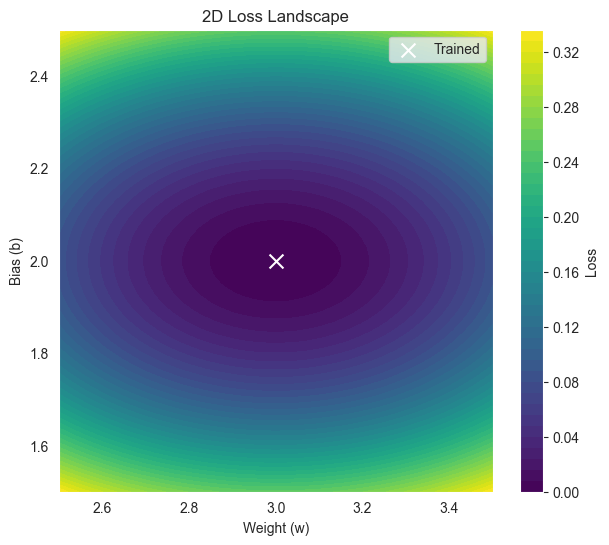

In [2]:
import matplotlib.pyplot as plt

torch.manual_seed(42)
loss_fn = nn.MSELoss()

# DATASET: Linear Regression (y = 3x + 2)
X = torch.linspace(-1, 1, 100).reshape(-1, 1)
Y = 3 * X + 2

# MODEL: 2 parameters (weight and bias)
model = nn.Linear(1, 1)

# TRAIN to convergence
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
for step in range(500):
    optimizer.zero_grad()
    loss = nn.MSELoss()(model(X), Y)
    loss.backward()
    optimizer.step()

print(f"Trained: w={model.weight.item():.4f}, b={model.bias.item():.4f}, loss={loss.item():.6f}")

# LANDSCAPE VISUALIZATION
def plot_landscape(model, X, Y, center_w=None, center_b=None, span=0.5):
    if center_w is None:
        center_w = model.weight.item()
    if center_b is None:
        center_b = model.bias.item()

    saved_w = model.weight.data.clone()
    saved_b = model.bias.data.clone()

    w_range = torch.linspace(center_w - span, center_w + span, 50)
    b_range = torch.linspace(center_b - span, center_b + span, 50)
    W, B = torch.meshgrid(w_range, b_range, indexing='ij')
    Z = torch.zeros_like(W)

    for i in range(len(w_range)):
        for j in range(len(b_range)):
            model.weight.data = torch.tensor([[w_range[i]]])
            model.bias.data = torch.tensor([b_range[j]])
            with torch.no_grad():
                Z[i, j] = nn.MSELoss()(model(X), Y)

    # restore model weights
    model.weight.data = saved_w
    model.bias.data = saved_b

    fig, ax = plt.subplots(figsize=(7, 6))

    cf = ax.contourf(W, B, Z, levels=50, cmap='viridis')
    fig.colorbar(cf, ax=ax, label='Loss')
    ax.scatter([center_w], [center_b], marker='x', c='white', s=100, label='Trained', zorder=10)
    ax.set_xlabel('Weight (w)')
    ax.set_ylabel('Bias (b)')
    ax.set_title('2D Loss Landscape')
    ax.legend()

    return fig, ax

fig, ax = plot_landscape(model, X, Y)

The SGLD sampler produces a trajectory $w_0, w_1, \ldots, w_T$ through parameter space. To see how the sampler explores the local geometry, we overlay this trajectory on a 2D slice of the loss landscape (varying two parameters while holding the others fixed at their trained values).

The trace is colored by time step. The circle marks the start, the star marks the end.

Estimated LLC: 595.7900964365639


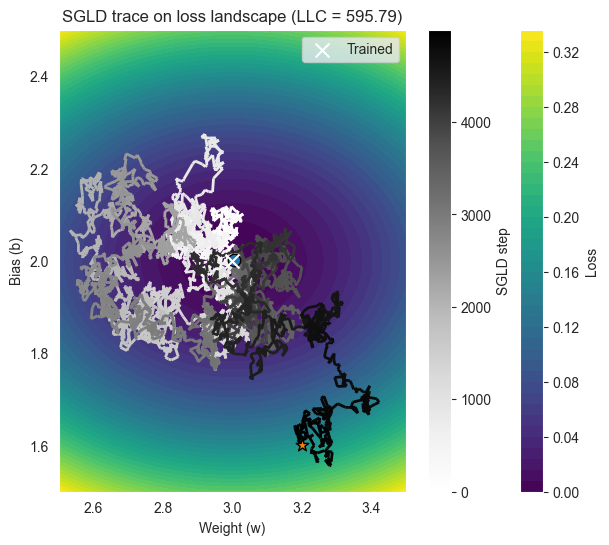

In [3]:
llc, path = estimate_llc_simple_sgld(model, X, Y)
print("Estimated LLC:", llc)

# Overlay the SGLD trace on the landscape
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

w_path = path[:, 0]
b_path = path[:, 1]

pts = np.column_stack([w_path, b_path])
T = len(pts)
segments = np.stack([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segments, cmap="Greys_r", norm=Normalize(0, T - 1))
lc.set_array(np.arange(T - 1))
lc.set_linewidth(2.0)
ax.add_collection(lc)

ax.scatter(pts[0, 0], pts[0, 1], marker="o", s=80, edgecolors="black", linewidths=1.0, zorder=5)
ax.scatter(pts[-1, 0], pts[-1, 1], marker="*", s=90, edgecolors="black", linewidths=1.0, zorder=5)

ax.set_xlabel("Weight (w)")
ax.set_ylabel("Bias (b)")
ax.set_title(f"SGLD trace on loss landscape (LLC = {llc:.2f})")
ax.legend()
fig.colorbar(lc, ax=ax, label="SGLD step")
fig

## Nonlinear Model: Single Hidden Neuron (4 parameters)

Now we move to a more interesting case: a tiny MLP with one hidden neuron and tanh activation:

$$f(x) = w_2 \tanh(w_1 x + b_1) + b_2$$

This has 4 learnable parameters $(w_1, b_1, w_2, b_2)$. Unlike the linear case, the loss landscape is non-convex and has symmetries (e.g., flipping the sign of $w_1$ and $w_2$ simultaneously gives the same function).

Several toy datasets are provided to experiment with:
- **step**: A step function ($\pm 1$) - a single tanh neuron fits this well
- **abs**: $|x|$ - has a cusp at 0, instructive for seeing the limits of a smooth activation
- **bump**: A localized Gaussian bump $e^{-3x^2}$ - learnable but shows limitations
- **sin_plus_trend**: $\sin(3x) + 0.3x$ - more complex than one neuron can perfectly represent, good for building intuition about model capacity

After training, we visualize all $\binom{4}{2} = 6$ pairwise slices of the loss landscape and run SGLD to explore the local geometry around the trained solution.

In [4]:
import itertools
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd

torch.manual_seed(0)

# TOY DATASETS (choose one)
#
def make_dataset(name="step", n=200):
    X = torch.linspace(-2, 2, n).reshape(-1, 1)

    if name == "step":
        # A smooth-ish step is perfect for a single tanh neuron.
        # True function: ~sign(x)
        Y = torch.where(X >= 0, torch.ones_like(X), -torch.ones_like(X))

    elif name == "abs":
        # |x|: interesting cusp at 0; one tanh neuron won't fit perfectly, but it's instructive.
        Y = torch.abs(X)

    elif name == "bump":
        # A localized bump: learnable-ish with tanh but will show limitations.
        Y = torch.exp(-3 * (X ** 2))

    elif name == "sin_plus_trend":
        # More complex than one neuron can fully represent
        Y = torch.sin(3 * X) + 0.3 * X

    else:
        raise ValueError("Unknown dataset name")

    return X, Y

# X, Y = make_dataset("step", n=200)
# X, Y = make_dataset("abs", n=200)
# X, Y = make_dataset("bump", n=200)
X, Y = make_dataset("sin_plus_trend", n=200)

pd.DataFrame({
    "X": X.squeeze().cpu().numpy(),
    "Y": Y.squeeze().cpu().numpy(),
})

,X,Y
0,-2.000000,-0.320585
1,-1.979900,-0.257198
2,-1.959799,-0.195035
3,-1.939698,-0.134301
4,-1.919598,-0.075193
...,...,...
195,1.919598,0.075193
196,1.939698,0.134301
197,1.959799,0.195035
198,1.979900,0.257198


Step 500: loss=0.435169
Step 1000: loss=0.355657
Step 1500: loss=0.349428
Step 2000: loss=0.347318


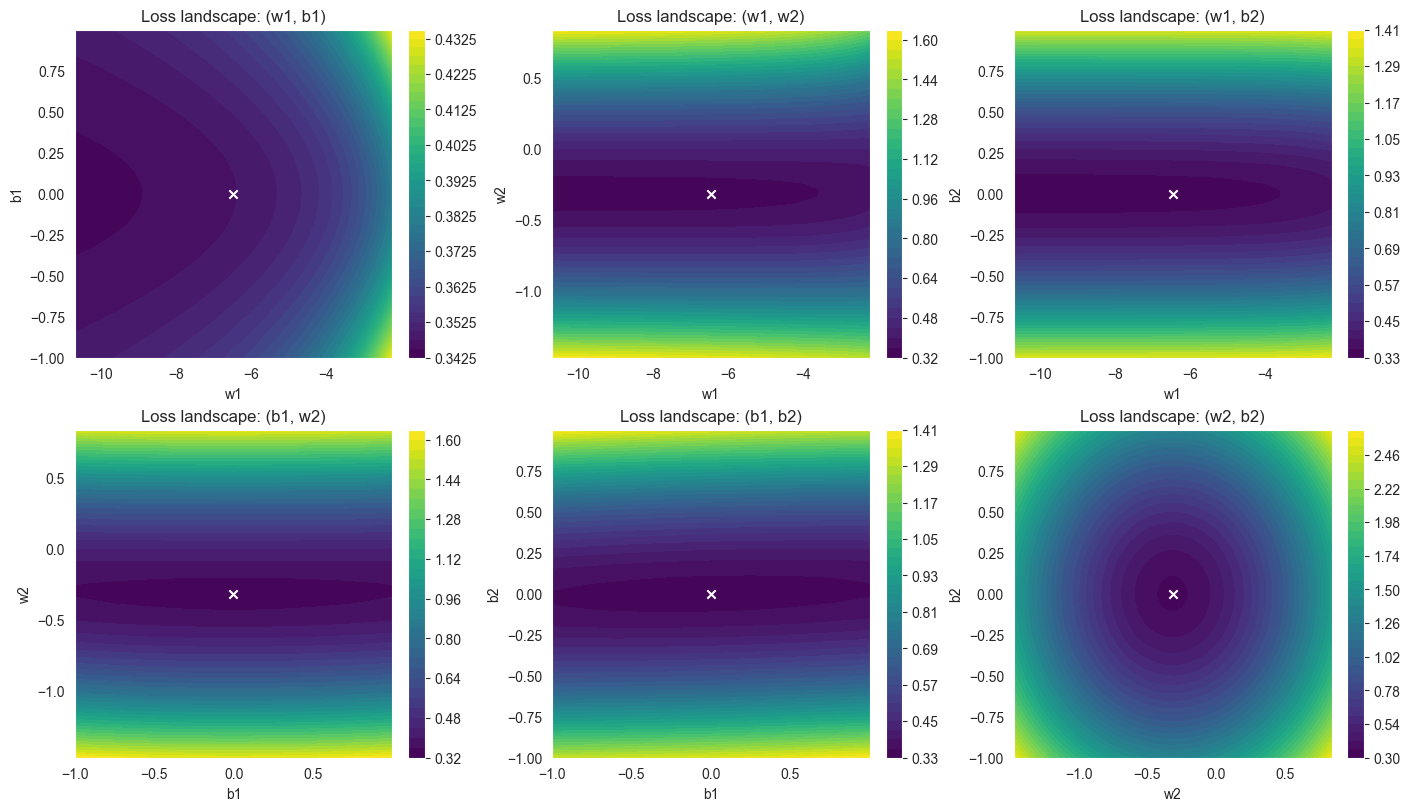

In [5]:
# NONLINEAR MODEL: 1 hidden neuron => 4 parameters
class TinyMLP1(nn.Module):
    def __init__(self, activation="tanh"):
        super().__init__()
        self.fc1 = nn.Linear(1, 1)   # w1, b1
        self.fc2 = nn.Linear(1, 1)   # w2, b2
        if activation == "tanh":
            self.act = torch.tanh
        elif activation == "relu":
            self.act = torch.relu
        else:
            raise ValueError("activation must be 'tanh' or 'relu'")

    def forward(self, x):
        h = self.act(self.fc1(x))
        yhat = self.fc2(h)
        return yhat

model = TinyMLP1(activation="tanh")

param_names = ["w1", "b1", "w2", "b2"]

# TRAIN A BIT
# so the landscape is meaningful around a solution
opt = optim.Adam(model.parameters(), lr=1e-2)
for step in range(2000):
    opt.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, Y)
    loss.backward()
    opt.step()

    if (step + 1) % 500 == 0:
        print(f"Step {step+1}: loss={loss.item():.6f}")

base_params = get_param_vector(model)

# PLOT ALL 6 PARAMETER-PAIR LANDSCAPES
def plot_all_pair_landscapes(model, X, Y, base_params, span=None, steps=60):
    base_params = base_params.clone()
    base_vals = {name: base_params[i].item() for i, name in enumerate(param_names)}

    if span is None:
        span = {}
        for i, name in enumerate(param_names):
            bv = abs(base_vals[name])
            span[name] = 1.0 + 0.5 * bv

    pairs = list(itertools.combinations(range(4), 2))
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

    for ax, (i, j) in zip(axes.flatten(), pairs):
        name_i, name_j = param_names[i], param_names[j]
        bi, bj = base_params[i].item(), base_params[j].item()

        ri = torch.linspace(bi - span[name_i], bi + span[name_i], steps)
        rj = torch.linspace(bj - span[name_j], bj + span[name_j], steps)

        Ii, Jj = torch.meshgrid(ri, rj, indexing="ij")
        Z = torch.zeros_like(Ii)

        for a in range(steps):
            for b in range(steps):
                v = base_params.clone()
                v[i] = Ii[a, b]
                v[j] = Jj[a, b]
                set_param_vector(model, v)
                with torch.no_grad():
                    Z[a, b] = loss_fn(model(X), Y)

        set_param_vector(model, base_params)

        cf = ax.contourf(Ii, Jj, Z, levels=40, cmap="viridis")
        fig.colorbar(cf, ax=ax)
        ax.set_xlabel(name_i)
        ax.set_ylabel(name_j)
        ax.set_title(f"Loss landscape: ({name_i}, {name_j})")
        ax.scatter([bi], [bj], marker="x", color="white")

    plt.show()

plot_all_pair_landscapes(model, X, Y, base_params, steps=50)


## Visualizing SGLD Traces on the Loss Landscape

Since the model has 4 parameters, there are $\binom{4}{2} = 6$ distinct 2D slices through the loss landscape. Viewing them all at once reveals which parameter pairs the sampler explores freely and where it stays tightly concentrated.

Estimated LLC: 508.2668581008909


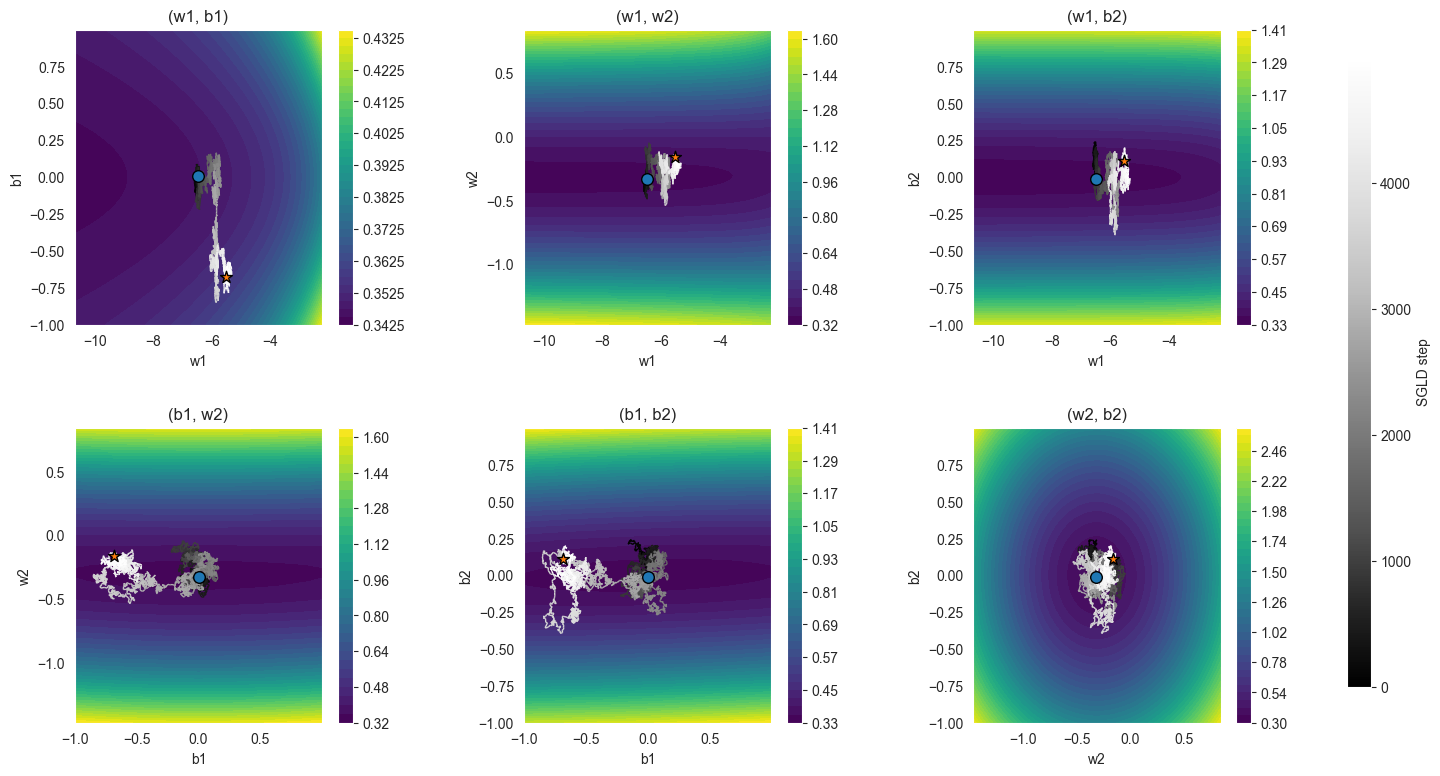

In [6]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

llc_est, path = estimate_llc_simple_sgld(model, X, Y, eps=0.01, lr=1e-3)
print("Estimated LLC:", llc_est)

def plot_all_landscapes_with_trace(
    model, X, Y, loss_fn,
    base_params, path,
    span=None, steps=70, levels=40
):
    """
    Plots all 6 pairwise 2D loss landscapes for a 4-parameter model,
    with the SGLD trace overlaid and colored by time.

    base_params: (4,) torch tensor (trained solution)
    path: (T,4) torch tensor (SGLD parameter samples)
    span: dict mapping param name -> half-width of plot range (same as plot_all_pair_landscapes)
    """

    device = next(model.parameters()).device
    base_params = base_params.detach().cpu()
    path = path.detach().cpu()
    T = path.shape[0]

    # Use same span logic as plot_all_pair_landscapes
    if span is None:
        span = {}
        for i, name in enumerate(param_names):
            bv = abs(base_params[i].item())
            span[name] = 1.0 + 0.5 * bv

    pairs = list(itertools.combinations(range(4), 2))  # 6 pairs

    # Save current params so we restore exactly after evals
    current_params = get_param_vector(model).detach().cpu()

    # --- Precompute Z grids ---
    grids = {}  # (i,j) -> (Ii, Jj, Z)

    for (i, j) in pairs:
        bi, bj = base_params[i].item(), base_params[j].item()
        name_i, name_j = param_names[i], param_names[j]

        ri = torch.linspace(bi - span[name_i], bi + span[name_i], steps)
        rj = torch.linspace(bj - span[name_j], bj + span[name_j], steps)
        Ii, Jj = torch.meshgrid(ri, rj, indexing="ij")
        Z = torch.zeros_like(Ii)

        base = base_params.clone()

        for a in range(steps):
            for b in range(steps):
                v = base.clone()
                v[i] = Ii[a, b]
                v[j] = Jj[a, b]
                set_param_vector(model, v.to(device))
                with torch.no_grad():
                    Z[a, b] = loss_fn(model(X), Y).detach().cpu()

        grids[(i, j)] = (Ii.numpy(), Jj.numpy(), Z.numpy())

    # restore params after precompute
    set_param_vector(model, current_params.to(device))

    # --- Plot 2x3 grid ---
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.subplots_adjust(right=0.88, wspace=0.45, hspace=0.35)

    # time color setup (shared across all subplots)
    time_norm = Normalize(vmin=0, vmax=max(T - 1, 1))

    for ax, (i, j) in zip(axes.flatten(), pairs):
        Ii, Jj, Z = grids[(i, j)]

        # loss background (independent color scale per subplot)
        cf = ax.contourf(Ii, Jj, Z, levels=levels, cmap='viridis')
        fig.colorbar(cf, ax=ax)

        # overlay time-colored trace in (i,j)
        pts = path[:, [i, j]].numpy()  # (T,2)
        if T >= 2:
            segments = np.stack([pts[:-1], pts[1:]], axis=1)  # (T-1,2,2)
            lc = LineCollection(segments, cmap='_r', norm=time_norm)
            lc.set_array(np.arange(T - 1))
            lc.set_linewidth(1.0)
            ax.add_collection(lc)

        # mark start/end
        ax.scatter(pts[0, 0], pts[0, 1], marker="o", s=70, edgecolors="black", linewidths=1.0, zorder=5)
        ax.scatter(pts[-1, 0], pts[-1, 1], marker="*", s=80, edgecolors="black", linewidths=1.0, zorder=5)

        ax.set_xlabel(param_names[i])
        ax.set_ylabel(param_names[j])
        ax.set_title(f"({param_names[i]}, {param_names[j]})")

    # SGLD step colorbar in dedicated axes on the right
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    time_sm = ScalarMappable(norm=time_norm, cmap='_r')
    fig.colorbar(time_sm, cax=cbar_ax, label="SGLD step")

    plt.show()

plot_all_landscapes_with_trace(
    model, X, Y, loss_fn,
    base_params=base_params,
    path=path
)

## LLC Over Training: The "Dev" in DevInterp

The local learning coefficient $\hat\lambda$ captures the effective complexity of the model at a given point in training. As the model learns, the local geometry of the loss landscape changes and so does $\hat\lambda$.

Below, we train a fresh model from scratch, saving checkpoints at regular intervals. At each checkpoint we run SGLD and estimate the LLC. We then plot:

1. **LLC vs training step** the developmental trajectory of model complexity
2. **SGLD traces at selected checkpoints** showing how the sampler explores different geometries at different stages of training (projected onto the $(w_1, b_1)$ plane)

In [7]:
import copy
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

torch.manual_seed(0)

# Train from scratch, saving checkpoints
model_dev = TinyMLP1(activation="tanh")
opt_dev = optim.Adam(model_dev.parameters(), lr=1e-2)

checkpoint_steps = [0, 25, 50, 100, 250, 500, 750, 1000]
checkpoints = {}  # step -> param vector
losses_over_training = []

# Save initial checkpoint (step 0)
checkpoints[0] = get_param_vector(model_dev).clone()

for step in range(1, max(checkpoint_steps) + 1):
    opt_dev.zero_grad()
    loss = loss_fn(model_dev(X), Y)
    loss.backward()
    opt_dev.step()
    losses_over_training.append((step, loss.item()))

    if step in checkpoint_steps:
        checkpoints[step] = get_param_vector(model_dev).clone()
        print(f"step {step}: loss={loss.item():.6f}")

# Estimate LLC at each checkpoint
llc_over_training = []
paths_at_checkpoints = {}

for step in checkpoint_steps:
    set_param_vector(model_dev, checkpoints[step])
    llc, sgld_path = estimate_llc_simple_sgld(
        model_dev, X, Y, eps=0.01, lr=1e-3
    )
    llc_over_training.append((step, llc))
    paths_at_checkpoints[step] = sgld_path
    print(f"Step {step}: LLC={llc:.4f}")

print("\nDone.")

step 25: loss=0.896007
step 50: loss=0.578144
step 100: loss=0.445012
step 250: loss=0.435557
step 500: loss=0.435169
step 750: loss=0.371450
step 1000: loss=0.355657
Step 0: LLC=-24893.2840
Step 25: LLC=-7708.3383
Step 50: LLC=-2009.3663
Step 100: LLC=567.2479
Step 250: LLC=1105.6401
Step 500: LLC=324.4001
Step 750: LLC=798.1136
Step 1000: LLC=1278.5742

Done.


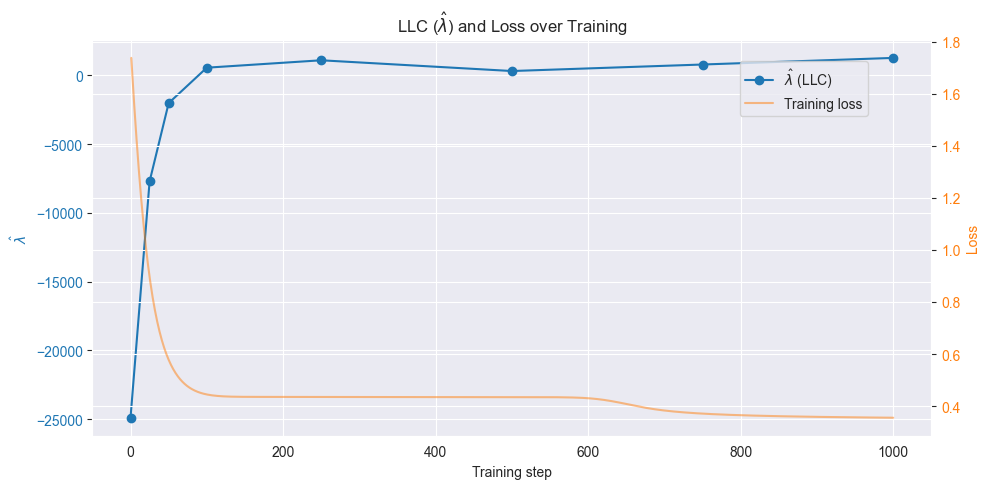

In [8]:
# LLC and Loss over training
fig, ax1 = plt.subplots(figsize=(10, 5))

steps_llc, vals_llc = zip(*llc_over_training)
ax1.plot(steps_llc, vals_llc, "o-", color="tab:blue", label=r"$\hat\lambda$ (LLC)")
ax1.set_xlabel("Training step")
ax1.set_ylabel(r"$\hat\lambda$", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
steps_loss, vals_loss = zip(*losses_over_training)
ax2.plot(steps_loss, vals_loss, "-", color="tab:orange", alpha=0.5, label="Training loss")
ax2.set_ylabel("Loss", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
ax1.set_title(r"LLC ($\hat\lambda$) and Loss over Training")
plt.tight_layout()
plt.show()

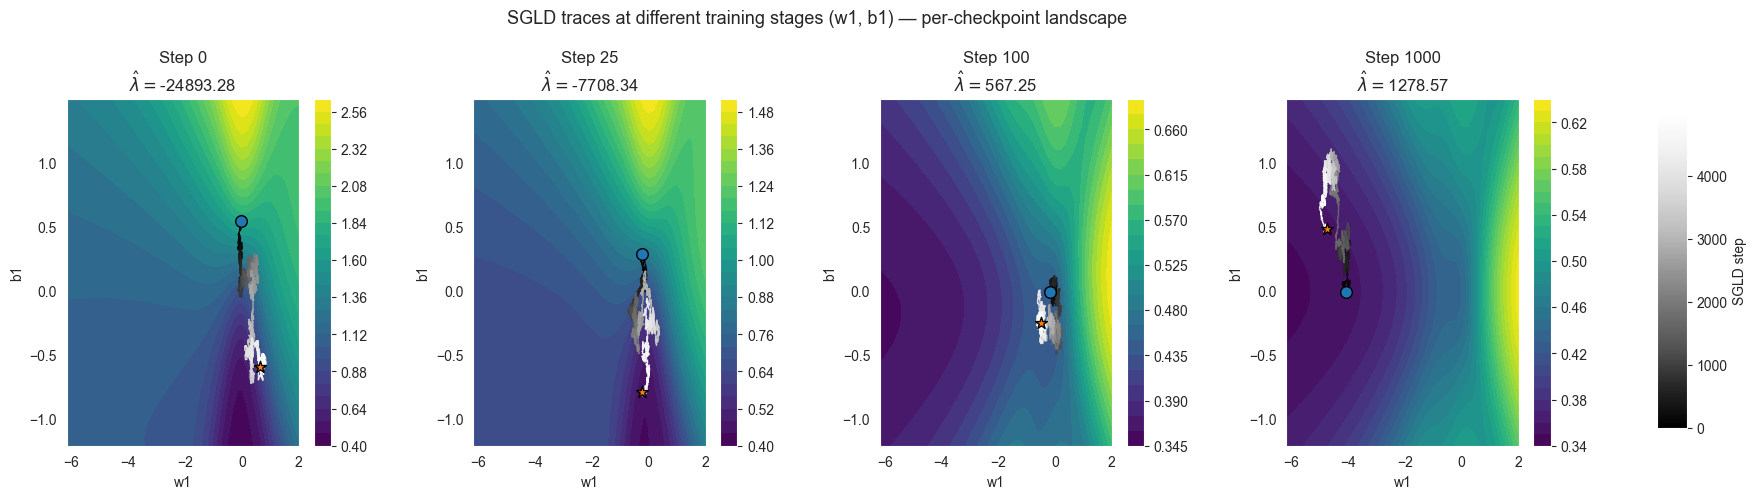

In [9]:
def plot_sgld_traces_over_training(
    model, X, Y, checkpoints, paths_at_checkpoints, llc_over_training,
    display_steps, pi=0, pj=0, margin=0.2, grid_steps=50, levels=30,
    fixed_params=None,
):
    """
    Plot SGLD traces at selected checkpoints on a 2D loss landscape slice.

    If fixed_params is given, the landscape background uses those fixed values
    for all non-swept parameters (same slice across all subplots).
    Otherwise, each subplot uses its own checkpoint's parameters (landscape
    changes between subplots because the held-fixed params differ).
    """
    # Compute unified axis range across all displayed checkpoints
    all_vals_i, all_vals_j = [], []
    for step in display_steps:
        sgld_path = paths_at_checkpoints[step].detach().cpu()
        all_vals_i.append(sgld_path[:, pi])
        all_vals_i.append(checkpoints[step][pi].view(1))
        all_vals_j.append(sgld_path[:, pj])
        all_vals_j.append(checkpoints[step][pj].view(1))

    all_vals_i = torch.cat(all_vals_i)
    all_vals_j = torch.cat(all_vals_j)
    i_min, i_max = all_vals_i.min().item(), all_vals_i.max().item()
    j_min, j_max = all_vals_j.min().item(), all_vals_j.max().item()
    i_span = max(i_max - i_min, 0.5)
    j_span = max(j_max - j_min, 0.5)

    ri = torch.linspace(i_min - margin * i_span, i_max + margin * i_span, grid_steps)
    rj = torch.linspace(j_min - margin * j_span, j_max + margin * j_span, grid_steps)
    Ii, Jj = torch.meshgrid(ri, rj, indexing="ij")

    fig, axes = plt.subplots(1, len(display_steps), figsize=(5 * len(display_steps), 4.5))
    fig.subplots_adjust(right=0.88, wspace=0.4)

    # shared time norm across all subplots
    max_T = max(paths_at_checkpoints[s].shape[0] for s in display_steps)
    time_norm = Normalize(vmin=0, vmax=max(max_T - 1, 1))

    for ax, step in zip(axes, display_steps):
        params = checkpoints[step]
        sgld_path = paths_at_checkpoints[step].detach().cpu()

        # Use fixed_params for the landscape base if provided, otherwise checkpoint params
        base = fixed_params.clone() if fixed_params is not None else params.clone()

        Z = torch.zeros_like(Ii)
        for a in range(grid_steps):
            for b in range(grid_steps):
                v = base.clone()
                v[pi] = Ii[a, b]
                v[pj] = Jj[a, b]
                set_param_vector(model, v)
                with torch.no_grad():
                    Z[a, b] = loss_fn(model(X), Y)

        cf = ax.contourf(Ii.numpy(), Jj.numpy(), Z.numpy(), levels=levels, cmap="viridis")
        fig.colorbar(cf, ax=ax)

        # trace colored by time
        pts = sgld_path[:, [pi, pj]].numpy()
        T = len(pts)
        if T >= 2:
            segments = np.stack([pts[:-1], pts[1:]], axis=1)
            lc = LineCollection(segments, cmap="Greys_r", norm=time_norm)
            lc.set_array(np.arange(T - 1))
            lc.set_linewidth(1.0)
            ax.add_collection(lc)

        # mark start/end
        ax.scatter(pts[0, 0], pts[0, 1], marker="o", s=70, edgecolors="black", linewidths=1.0, zorder=5)
        ax.scatter(pts[-1, 0], pts[-1, 1], marker="*", s=80, edgecolors="black", linewidths=1.0, zorder=5)

        llc_val = dict(llc_over_training)[step]
        ax.set_title(f"Step {step}\n" + r"$\hat\lambda=$" + f"{llc_val:.2f}")
        ax.set_xlabel(param_names[pi])
        ax.set_ylabel(param_names[pj])

    # Restore model
    set_param_vector(model, checkpoints[max(checkpoints)])

    # SGLD step colorbar in dedicated axes on the right
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    time_sm = ScalarMappable(norm=time_norm, cmap="Greys_r")
    fig.colorbar(time_sm, cax=cbar_ax, label="SGLD step")

    mode = "fixed final" if fixed_params is not None else "per-checkpoint"
    fig.suptitle(
        f"SGLD traces at different training stages ({param_names[pi]}, {param_names[pj]}) "
        f"— {mode} landscape",
        fontsize=13, y=1.08,
    )
    plt.show()

display_steps = [0, 25, 100, 1000]
pi, pj = 0, 1

# Per-checkpoint landscape: w2, b2 vary with each checkpoint, so the
# background surface changes between subplots.
plot_sgld_traces_over_training(
    model_dev, X, Y, checkpoints, paths_at_checkpoints, llc_over_training,
    display_steps, pi=pi, pj=pj,
)

The previous charts use the corresponding checkpointed values of the unplotted parameters. This is evident from the changing loss contour maps.

We thought it would be interesting to have a "fixed" landscape with regards to the plotted parameters, so in the following chart I clamped $w_2$ and $b_2$ at their final values when calculating the loss contour map. The result is similar but the 2D loss map is the consistent across the checkpoints, making it easier to see how the sampler's starting point moves toward the basin over the course of training.

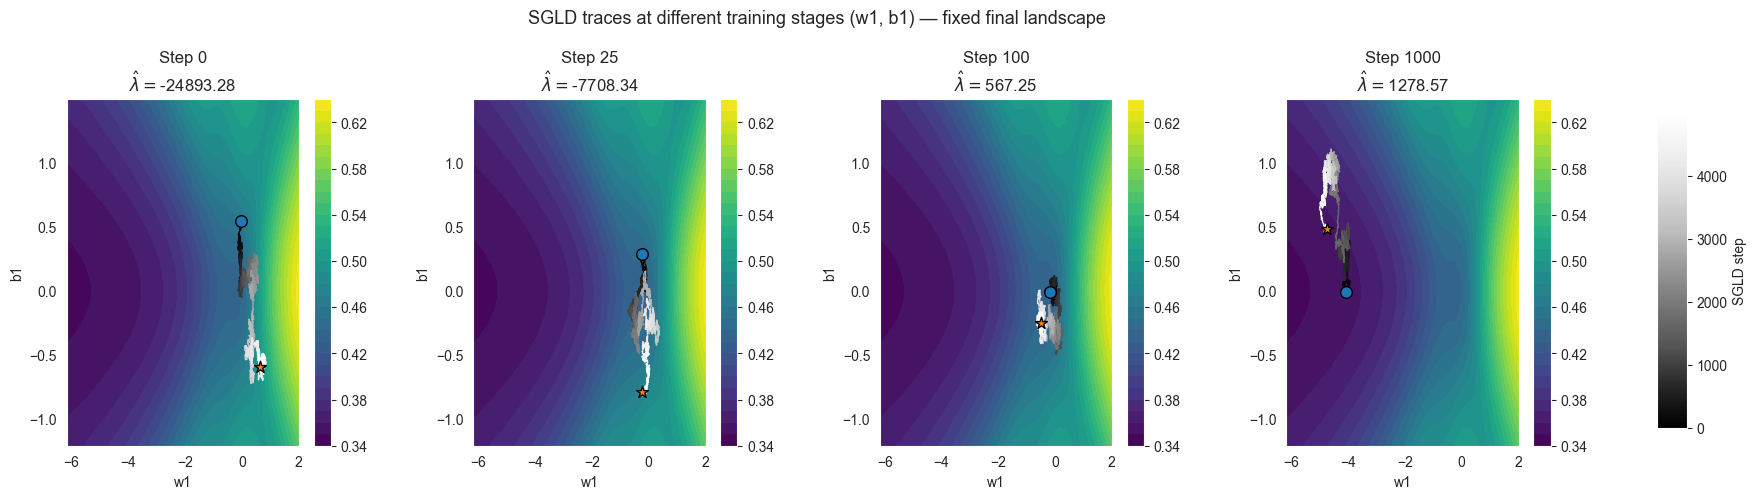

In [10]:
plot_sgld_traces_over_training(
    model_dev, X, Y, checkpoints, paths_at_checkpoints, llc_over_training,
    display_steps, pi=pi, pj=pj,
    fixed_params=checkpoints[max(checkpoints)],
)